# Origen del apellido, posición en cédula y resultados electorales
# Elecciones municipales distritales, Perú 2006–2022

¿La posición en la cédula de votación tiene un efecto diferenciado
según el origen lingüístico del apellido del candidato (quechua, aymara,
castellano, extranjero)? ¿El origen del apellido interactúa con la
región geográfica?

Se estima, para cada año por separado:

$$P(\text{ganar}_i) = \beta_0 + \beta_1 \text{pos}_i + \sum_k \beta_{2k} \text{origen}_{ik} + \sum_k \beta_{3k} (\text{pos}_i \times \text{origen}_{ik}) + \beta_4 \text{mujer}_i + \gamma\, n\_cand_i + \sum_j \delta_j \text{depto}_j + \varepsilon_i$$

**Fuentes:** JNE (candidatos), ONPE (resultados y posición en cédula).

**Estructura:**
1. Carga de datos y distribución general de orígenes
2. Análisis por año (2006 – 2022)
3. Comparación entre años

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import statsmodels.formula.api as smf
import warnings, os
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150, 'font.size': 11, 'font.family': 'serif',
    'axes.titlesize': 13, 'axes.labelsize': 11, 'legend.fontsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

BASE = os.path.dirname(os.path.abspath('__file__'))
if not os.path.exists(os.path.join(BASE, 'alcaldes_con_votos')):
    BASE = r'C:\Users\Usuario\Documents\GitHub\Forest_Peru\apellidos'

COLORES = {'CASTELLANO':'#2c3e50', 'QUECHUA':'#e74c3c',
           'AYMARA':'#f39c12', 'EXTRANJERO':'#27ae60'}
MARCADORES = {'CASTELLANO':'o', 'QUECHUA':'s', 'AYMARA':'^', 'EXTRANJERO':'D'}

## 1. Carga de datos y distribución general

In [2]:
frames = []
for year in [2006, 2010, 2014, 2018, 2022]:
    path = os.path.join(BASE, 'alcaldes_con_votos', f'alcaldes_con_votos_{year}.csv')
    df = pd.read_csv(path, encoding='utf-8-sig')
    df.columns = [c.strip() for c in df.columns]
    df['año'] = year
    frames.append(df)

data = pd.concat(frames, ignore_index=True)
data['posicion_cedula'] = pd.to_numeric(data['posicion_cedula'], errors='coerce')
data['total_votos'] = pd.to_numeric(data['total_votos'], errors='coerce')
data['ganador'] = pd.to_numeric(data['ganador'], errors='coerce')
data['mujer'] = (data['sexo'].str.strip().str.upper() == 'F').astype(int)
data['n_candidatos'] = data.groupby(['ubigeo','año'])['ganador'].transform('count')

# Normalizar nombre de departamento a mayúsculas
data['departamento'] = data['departamento'].str.upper().str.strip()

# Región natural
COSTA = {'TUMBES','PIURA','LAMBAYEQUE','LA LIBERTAD','ANCASH',
         'LIMA','CALLAO','ICA','AREQUIPA','MOQUEGUA','TACNA'}
SIERRA = {'CAJAMARCA','HUANUCO','PASCO','JUNIN','HUANCAVELICA',
          'AYACUCHO','APURIMAC','CUSCO','PUNO'}
SELVA = {'AMAZONAS','SAN MARTIN','LORETO','UCAYALI','MADRE DE DIOS'}

def region(d):
    if pd.isna(d): return 'OTRO'
    d = d.strip().upper()
    # Normalizar variantes con tilde
    import unicodedata
    d = unicodedata.normalize('NFD', d)
    d = ''.join(c for c in d if unicodedata.category(c) != 'Mn')
    if d in COSTA: return 'COSTA'
    if d in SIERRA: return 'SIERRA'
    if d in SELVA: return 'SELVA'
    return 'OTRO'

data['region'] = data['departamento'].apply(region)

print(f'Observaciones: {len(data):,}')
print(f'Con posición: {data["posicion_cedula"].notna().sum():,}')
print(f'\nOrigen del apellido:')
print(data['origen_apellido'].value_counts().to_string())
print(f'\nRegión:')
print(data['region'].value_counts().to_string())

Observaciones: 56,168
Con posición: 53,464

Origen del apellido:
origen_apellido
CASTELLANO    49496
QUECHUA        4785
AYMARA         1605
EXTRANJERO      282

Región:
region
SIERRA    26317
COSTA     23631
SELVA      6220


In [3]:
# Distribución por región (tabla)
tab_reg = pd.crosstab(data['region'], data['origen_apellido'], normalize='index') * 100
tab_reg = tab_reg[['CASTELLANO','QUECHUA','AYMARA','EXTRANJERO']].round(1)
print('Distribución del origen del apellido por región (%)')
print(tab_reg.to_string())

Distribución del origen del apellido por región (%)
origen_apellido  CASTELLANO  QUECHUA  AYMARA  EXTRANJERO
region                                                  
COSTA                  91.6      5.6     2.2         0.6
SELVA                  95.3      3.1     0.9         0.8
SIERRA                 83.3     12.4     3.9         0.3


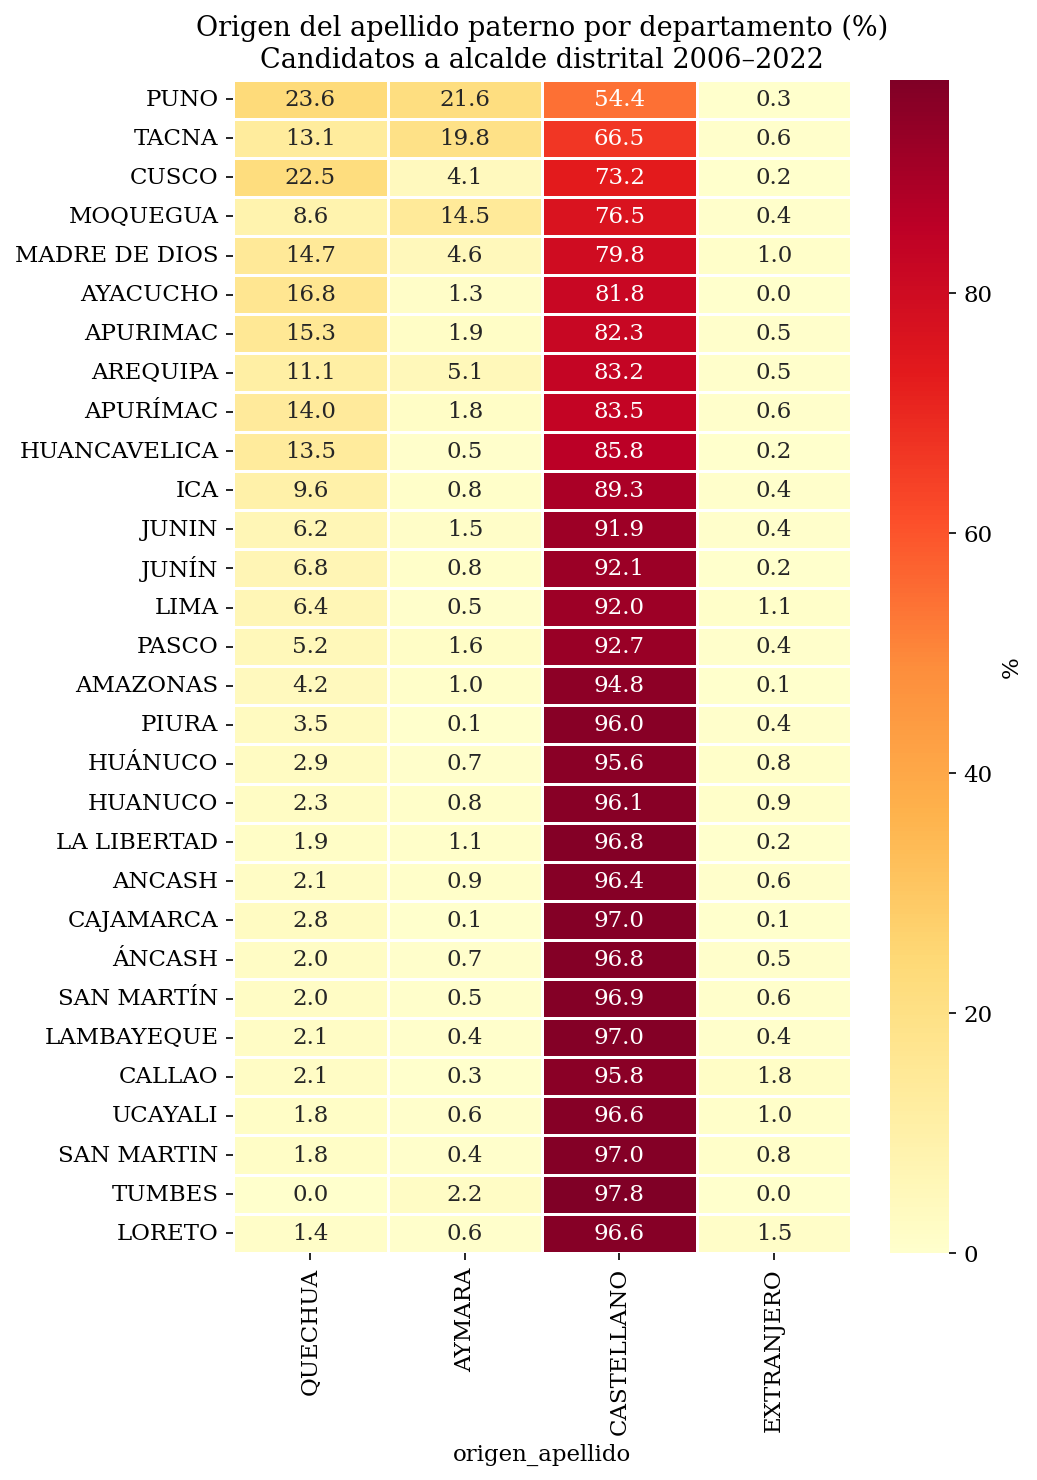

In [4]:
# Heatmap: origen por departamento (pool)
tab_d = pd.crosstab(data['departamento'], data['origen_apellido'], normalize='index') * 100
tab_d = tab_d.round(1)
tab_d['_ind'] = tab_d.get('QUECHUA',0) + tab_d.get('AYMARA',0)
tab_d = tab_d.sort_values('_ind', ascending=False).drop(columns='_ind')

cols = [c for c in ['QUECHUA','AYMARA','CASTELLANO','EXTRANJERO'] if c in tab_d.columns]
fig, ax = plt.subplots(figsize=(7, 10))
sns.heatmap(tab_d[cols], annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label':'%'})
ax.set_title('Origen del apellido paterno por departamento (%)\n'
             'Candidatos a alcalde distrital 2006–2022')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'fig_origen_departamento.png'), dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# Tasa de victoria global por origen
print('Tasa de victoria por origen del apellido (pool 2006–2022):')
for orig, g in data.groupby('origen_apellido'):
    n = len(g)
    w = int(g['ganador'].sum())
    print(f'  {orig:<15}  {w/n*100:.2f}%  (N={n:,}, ganadores={w:,})')

Tasa de victoria por origen del apellido (pool 2006–2022):
  AYMARA           15.39%  (N=1,605, ganadores=247)
  CASTELLANO       14.69%  (N=49,496, ganadores=7,273)
  EXTRANJERO       14.54%  (N=282, ganadores=41)
  QUECHUA          15.24%  (N=4,785, ganadores=729)


---

A continuación, cada proceso electoral se analiza por separado.
Para cada año se reporta:
- Distribución de orígenes y tasa de victoria por origen
- Gráfico de P(ganar) por posición y origen
- Tasa de victoria por origen y región
- MPL con interacciones posición×origen y EF de departamento

In [6]:
def analisis_anual_apellidos(data_año, year):
    """Análisis completo por año para origen de apellido."""
    da = data_año.copy()
    n = len(da)
    n_pos = da['posicion_cedula'].notna().sum()
    
    # --- Descriptivas ---
    print(f'Candidatos: {n:,}  |  Distritos: {da["ubigeo"].nunique():,}  |  '
          f'Con posición: {n_pos:,} ({n_pos/n*100:.1f}%)')
    print()
    
    print('Origen del apellido y tasa de victoria:')
    for orig in ['CASTELLANO','QUECHUA','AYMARA','EXTRANJERO']:
        sub = da[da['origen_apellido']==orig]
        if len(sub) == 0: continue
        w = int(sub['ganador'].sum())
        print(f'  {orig:<15}  N={len(sub):>5,}  ({len(sub)/n*100:>5.1f}%)  '
              f'Tasa victoria: {w/len(sub)*100:.2f}%')
    
    # --- Tasa por origen × región ---
    print()
    pivot = da.groupby(['region','origen_apellido'])['ganador'].agg(['mean','count']).reset_index()
    pt = pivot.pivot(index='origen_apellido', columns='region', values='mean')
    if pt is not None and not pt.empty:
        print('Tasa de victoria por origen y región (%):')
        print((pt * 100).round(2).to_string())
    
    # --- Gráfico: P(ganar) por posición y origen ---
    dv = da.dropna(subset=['posicion_cedula','ganador']).copy()
    dv['pos_grupo'] = dv['posicion_cedula'].clip(upper=10).astype(int)
    
    fig, ax = plt.subplots(figsize=(10, 5.5))
    for orig in ['CASTELLANO','QUECHUA','AYMARA','EXTRANJERO']:
        sub = dv[dv['origen_apellido']==orig].groupby('pos_grupo')['ganador'].agg(['mean','count'])
        sub = sub[sub['count'] >= 10]  # filtrar celdas con pocas observaciones
        if len(sub) >= 3:
            ax.plot(sub.index, sub['mean'], marker=MARCADORES.get(orig,'o'),
                    color=COLORES.get(orig,'gray'), lw=2, ms=6, label=orig.title())
    ax.set_xlabel('Posición en la cédula')
    ax.set_ylabel('P(ganar)')
    ax.set_title(f'P(ganar) según posición en cédula, por origen del apellido — {year}')
    ax.legend(title='Origen', frameon=False)
    ax.set_xticks(range(1,11))
    ax.set_xticklabels([str(i) for i in range(1,10)]+['10+'])
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    plt.tight_layout()
    plt.savefig(os.path.join(BASE, f'fig_posicion_x_origen_{year}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # --- Regresión MPL con interacción pos×origen + EF departamento ---
    reg = dv[['ganador','posicion_cedula','origen_apellido','mujer',
              'n_candidatos','departamento']].dropna().copy()
    if len(reg) < 100:
        print('Muestra insuficiente.')
        return None
    
    reg['origen_apellido'] = pd.Categorical(
        reg['origen_apellido'],
        categories=['CASTELLANO','QUECHUA','AYMARA','EXTRANJERO'])
    
    mod = smf.ols(
        'ganador ~ posicion_cedula * C(origen_apellido) + mujer + n_candidatos + C(departamento)',
        data=reg
    ).fit(cov_type='HC1')
    
    # Mostrar coeficientes de interés
    vars_show = ['posicion_cedula',
                 'C(origen_apellido)[T.QUECHUA]',
                 'C(origen_apellido)[T.AYMARA]',
                 'C(origen_apellido)[T.EXTRANJERO]',
                 'posicion_cedula:C(origen_apellido)[T.QUECHUA]',
                 'posicion_cedula:C(origen_apellido)[T.AYMARA]',
                 'posicion_cedula:C(origen_apellido)[T.EXTRANJERO]',
                 'mujer', 'n_candidatos']
    
    print(f'\nMPL con EF departamento — N = {int(mod.nobs):,}   R² = {mod.rsquared:.4f}')
    print(f'Ref.: CASTELLANO')
    print(f'{"Variable":<55} {"Coef(pp)":>9} {"SE":>8} {"p":>7}')
    print('-'*82)
    for v in vars_show:
        if v in mod.params.index:
            sig = '***' if mod.pvalues[v]<0.01 else '**' if mod.pvalues[v]<0.05 \
                  else '*' if mod.pvalues[v]<0.1 else ''
            print(f'{v:<55} {mod.params[v]*100:>+9.3f} {mod.bse[v]*100:>8.3f} '
                  f'{mod.pvalues[v]:>7.4f} {sig}')
    
    # Efecto neto de posición por origen
    b_pos = mod.params['posicion_cedula']
    print(f'\nEfecto neto de posición:')
    print(f'  Castellano (ref.): {b_pos*100:+.3f} pp')
    for orig in ['QUECHUA','AYMARA','EXTRANJERO']:
        key = f'posicion_cedula:C(origen_apellido)[T.{orig}]'
        if key in mod.params.index:
            total = b_pos + mod.params[key]
            print(f'  {orig:<15}: {total*100:+.3f} pp')
    
    return mod

## 2. Elecciones municipales 2006

Candidatos: 11,155  |  Distritos: 1,636  |  Con posición: 11,059 (99.1%)

Origen del apellido y tasa de victoria:
  CASTELLANO       N=9,819  ( 88.0%)  Tasa victoria: 14.59%
  QUECHUA          N=  930  (  8.3%)  Tasa victoria: 15.91%
  AYMARA           N=  336  (  3.0%)  Tasa victoria: 12.50%
  EXTRANJERO       N=   70  (  0.6%)  Tasa victoria: 18.57%

Tasa de victoria por origen y región (%):
region           COSTA  SELVA  SIERRA
origen_apellido                      
AYMARA           16.49  10.00   10.92
CASTELLANO       14.45  17.64   13.97
EXTRANJERO       21.21  33.33    8.00
QUECHUA          21.43   5.41   14.65


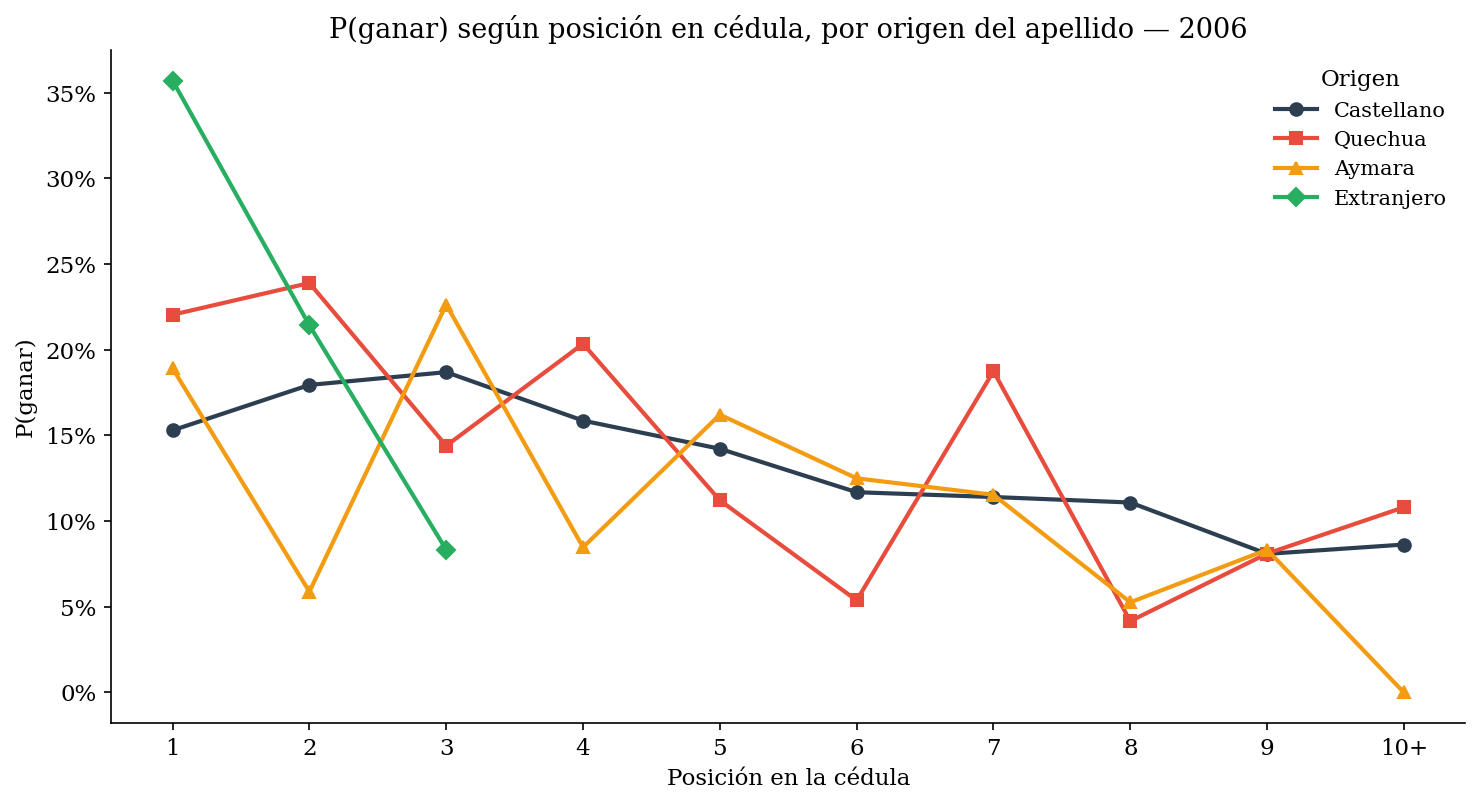


MPL con EF departamento — N = 11,059   R² = 0.0247
Ref.: CASTELLANO
Variable                                                 Coef(pp)       SE       p
----------------------------------------------------------------------------------
posicion_cedula                                            -0.073    0.130  0.5752 
C(origen_apellido)[T.QUECHUA]                              +5.722    2.532  0.0238 **
C(origen_apellido)[T.AYMARA]                               +1.165    3.692  0.7524 
C(origen_apellido)[T.EXTRANJERO]                           +9.344    8.852  0.2912 
posicion_cedula:C(origen_apellido)[T.QUECHUA]              -0.936    0.441  0.0337 **
posicion_cedula:C(origen_apellido)[T.AYMARA]               -0.530    0.576  0.3573 
posicion_cedula:C(origen_apellido)[T.EXTRANJERO]           -1.061    1.815  0.5589 
mujer                                                      -6.041    1.122  0.0000 ***
n_candidatos                                               -1.713    0.134  0.0000 ***

In [7]:
mod_2006 = analisis_anual_apellidos(data[data['año']==2006], 2006)

## 3. Elecciones municipales 2010

Candidatos: 11,419  |  Distritos: 1,638  |  Con posición: 11,137 (97.5%)

Origen del apellido y tasa de victoria:
  CASTELLANO       N=10,039  ( 87.9%)  Tasa victoria: 14.28%
  QUECHUA          N=  994  (  8.7%)  Tasa victoria: 14.49%
  AYMARA           N=  330  (  2.9%)  Tasa victoria: 15.45%
  EXTRANJERO       N=   56  (  0.5%)  Tasa victoria: 16.07%

Tasa de victoria por origen y región (%):
region           COSTA  SELVA  SIERRA
origen_apellido                      
AYMARA           15.31  22.22   15.25
CASTELLANO       13.68  17.36   14.10
EXTRANJERO       14.81  20.00   15.79
QUECHUA          16.73  12.50   13.75


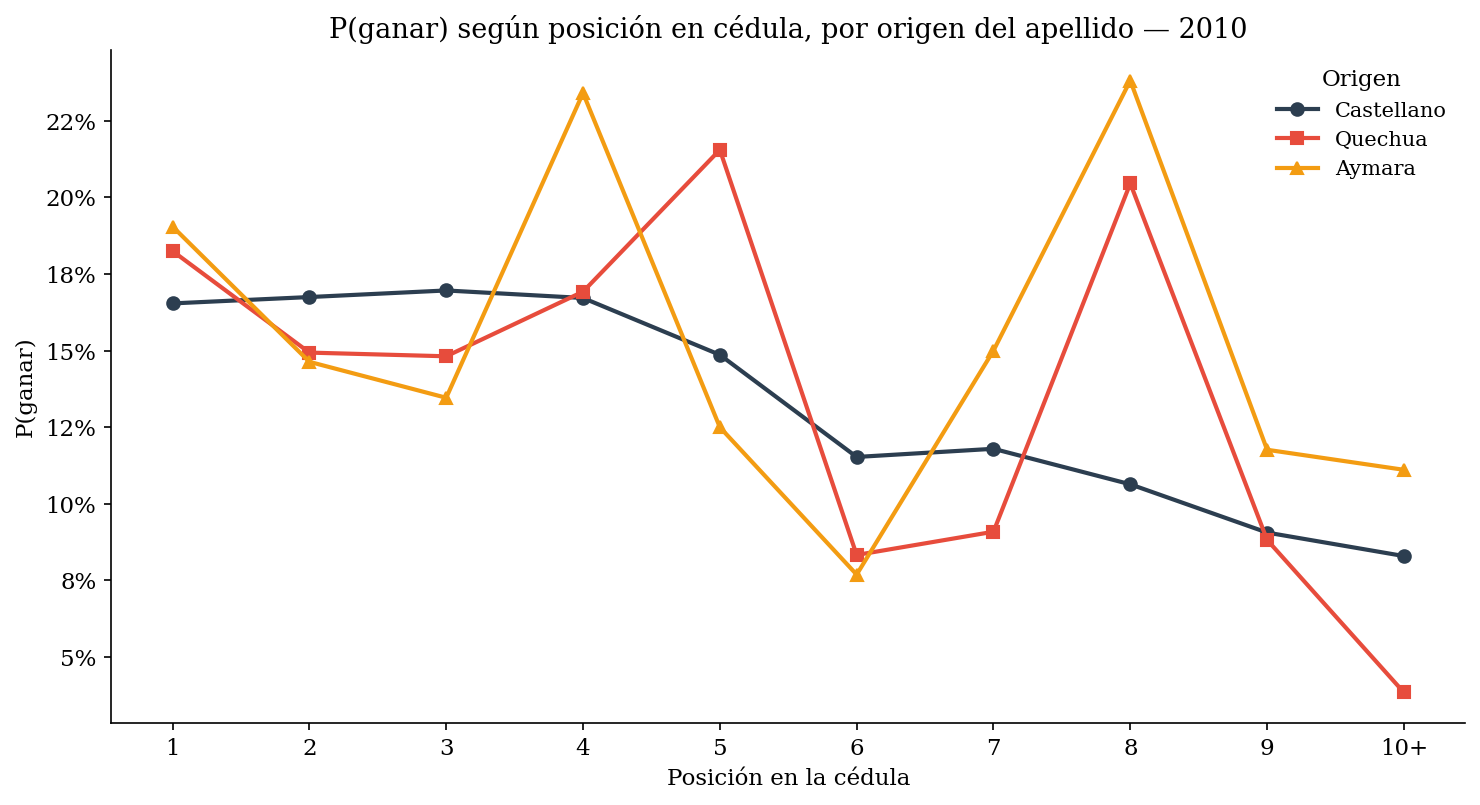


MPL con EF departamento — N = 11,137   R² = 0.0234
Ref.: CASTELLANO
Variable                                                 Coef(pp)       SE       p
----------------------------------------------------------------------------------
posicion_cedula                                            -0.019    0.133  0.8864 
C(origen_apellido)[T.QUECHUA]                              -0.240    2.260  0.9154 
C(origen_apellido)[T.AYMARA]                               -0.920    4.063  0.8208 
C(origen_apellido)[T.EXTRANJERO]                           -1.256   10.883  0.9081 
posicion_cedula:C(origen_apellido)[T.QUECHUA]              +0.012    0.385  0.9745 
posicion_cedula:C(origen_apellido)[T.AYMARA]               +0.470    0.728  0.5182 
posicion_cedula:C(origen_apellido)[T.EXTRANJERO]           +0.782    2.086  0.7078 
mujer                                                      -5.314    1.104  0.0000 ***
n_candidatos                                               -1.834    0.137  0.0000 ***

Ef

In [8]:
mod_2010 = analisis_anual_apellidos(data[data['año']==2010], 2010)

## 4. Elecciones municipales 2014

Candidatos: 11,535  |  Distritos: 1,647  |  Con posición: 11,455 (99.3%)

Origen del apellido y tasa de victoria:
  CASTELLANO       N=10,126  ( 87.8%)  Tasa victoria: 14.18%
  QUECHUA          N=1,003  (  8.7%)  Tasa victoria: 15.75%
  AYMARA           N=  353  (  3.1%)  Tasa victoria: 12.75%
  EXTRANJERO       N=   53  (  0.5%)  Tasa victoria: 15.09%

Tasa de victoria por origen y región (%):
region           COSTA  SELVA  SIERRA
origen_apellido                      
AYMARA           11.97  27.27   12.44
CASTELLANO       13.75  16.95   13.89
EXTRANJERO        9.38  14.29   28.57
QUECHUA          15.17  13.51   16.12


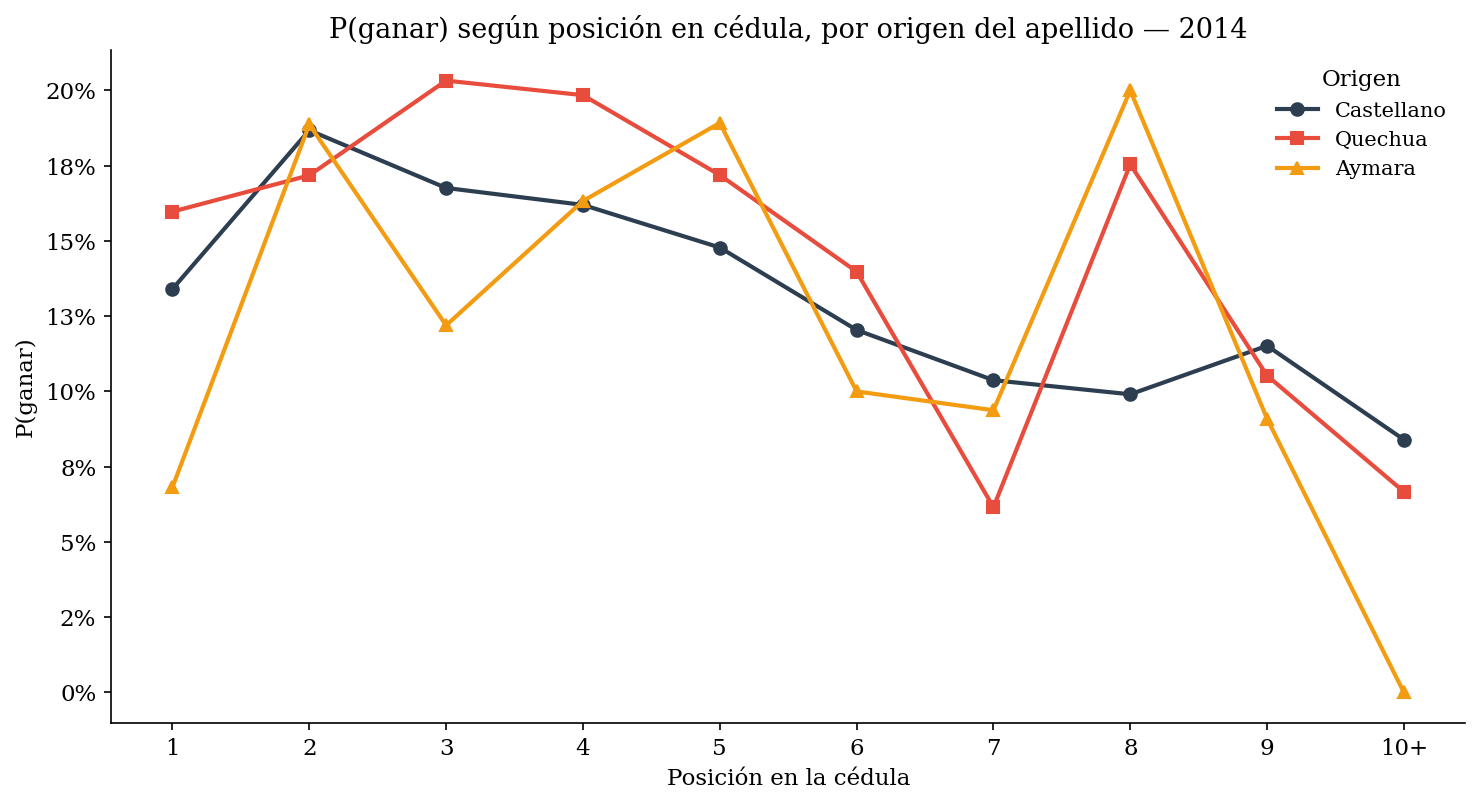


MPL con EF departamento — N = 11,455   R² = 0.0268
Ref.: CASTELLANO
Variable                                                 Coef(pp)       SE       p
----------------------------------------------------------------------------------
posicion_cedula                                            +0.194    0.121  0.1074 
C(origen_apellido)[T.QUECHUA]                              +3.073    2.223  0.1669 
C(origen_apellido)[T.AYMARA]                               -2.105    3.229  0.5144 
C(origen_apellido)[T.EXTRANJERO]                           +2.982   11.691  0.7986 
posicion_cedula:C(origen_apellido)[T.QUECHUA]              -0.319    0.369  0.3870 
posicion_cedula:C(origen_apellido)[T.AYMARA]               +0.146    0.489  0.7655 
posicion_cedula:C(origen_apellido)[T.EXTRANJERO]           +0.012    1.778  0.9946 
mujer                                                      -7.794    0.920  0.0000 ***
n_candidatos                                               -1.782    0.119  0.0000 ***

Ef

In [9]:
mod_2014 = analisis_anual_apellidos(data[data['año']==2014], 2014)

## 5. Elecciones municipales 2018

Candidatos: 12,160  |  Distritos: 1,678  |  Con posición: 10,831 (89.1%)

Origen del apellido y tasa de victoria:
  CASTELLANO       N=10,804  ( 88.8%)  Tasa victoria: 13.79%
  QUECHUA          N=  991  (  8.1%)  Tasa victoria: 12.82%
  AYMARA           N=  306  (  2.5%)  Tasa victoria: 18.63%
  EXTRANJERO       N=   59  (  0.5%)  Tasa victoria: 6.78%

Tasa de victoria por origen y región (%):
region           COSTA  SELVA  SIERRA
origen_apellido                      
AYMARA           21.70  28.57   16.13
CASTELLANO       12.47  15.18   14.78
EXTRANJERO        8.33   0.00   10.00
QUECHUA          13.21  10.26   12.80


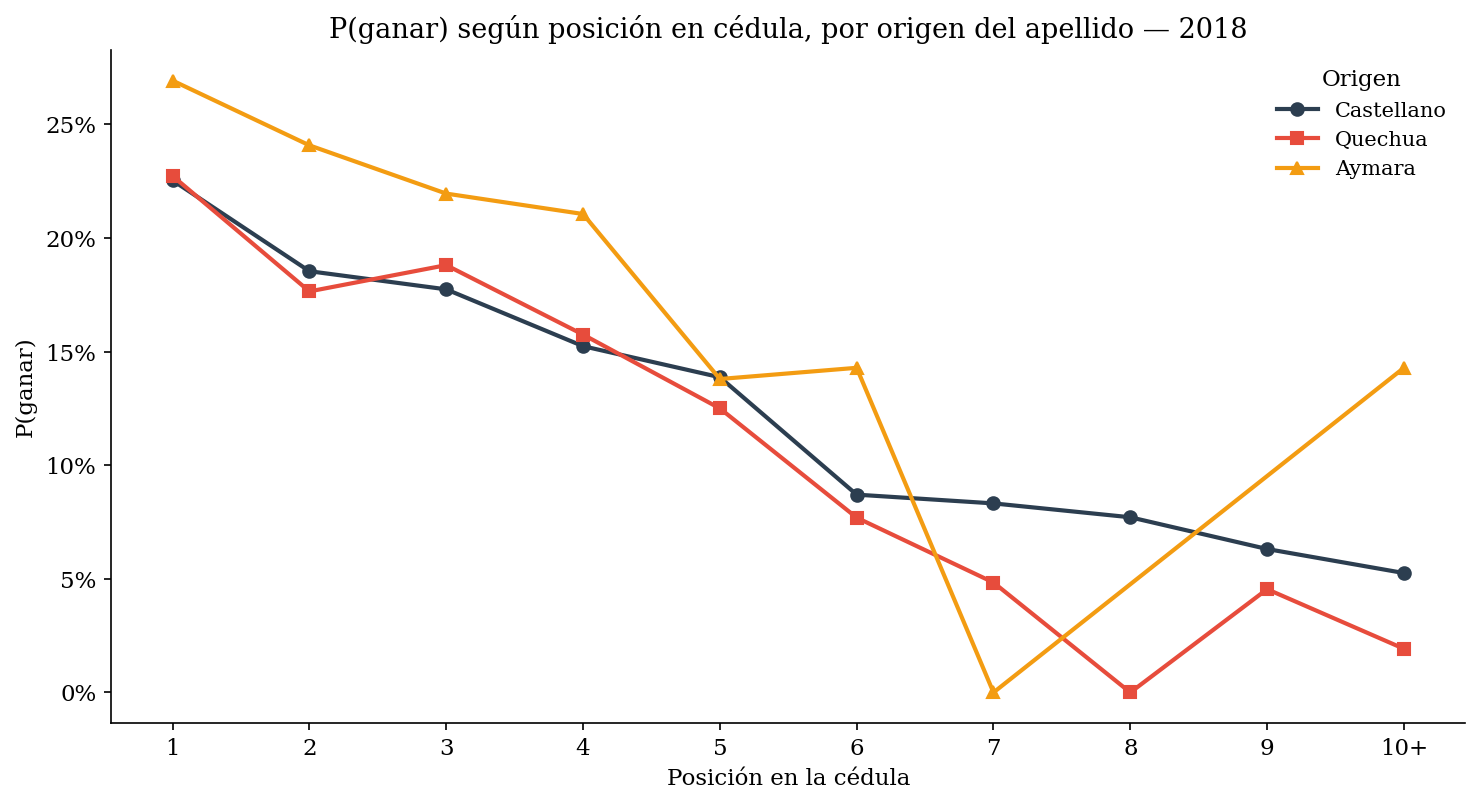


MPL con EF departamento — N = 10,831   R² = 0.0340
Ref.: CASTELLANO
Variable                                                 Coef(pp)       SE       p
----------------------------------------------------------------------------------
posicion_cedula                                            -0.905    0.123  0.0000 ***
C(origen_apellido)[T.QUECHUA]                              +1.177    2.380  0.6210 
C(origen_apellido)[T.AYMARA]                               +3.592    4.913  0.4647 
C(origen_apellido)[T.EXTRANJERO]                          -19.568    7.834  0.0125 **
posicion_cedula:C(origen_apellido)[T.QUECHUA]              -0.686    0.348  0.0491 **
posicion_cedula:C(origen_apellido)[T.AYMARA]               -0.169    0.996  0.8653 
posicion_cedula:C(origen_apellido)[T.EXTRANJERO]           +2.786    1.519  0.0666 *
mujer                                                      -5.252    0.961  0.0000 ***
n_candidatos                                               -0.926    0.106  0.0000

In [10]:
mod_2018 = analisis_anual_apellidos(data[data['año']==2018], 2018)

## 6. Elecciones municipales 2022

Candidatos: 9,899  |  Distritos: 1,691  |  Con posición: 8,982 (90.7%)

Origen del apellido y tasa de victoria:
  CASTELLANO       N=8,708  ( 88.0%)  Tasa victoria: 17.00%
  QUECHUA          N=  867  (  8.8%)  Tasa victoria: 17.53%
  AYMARA           N=  280  (  2.8%)  Tasa victoria: 18.57%
  EXTRANJERO       N=   44  (  0.4%)  Tasa victoria: 15.91%

Tasa de victoria por origen y región (%):
region           COSTA  SELVA  SIERRA
origen_apellido                      
AYMARA           15.62  20.00   20.11
CASTELLANO       15.49  17.58   18.45
EXTRANJERO        9.09  40.00   17.65
QUECHUA          14.50  10.53   19.46


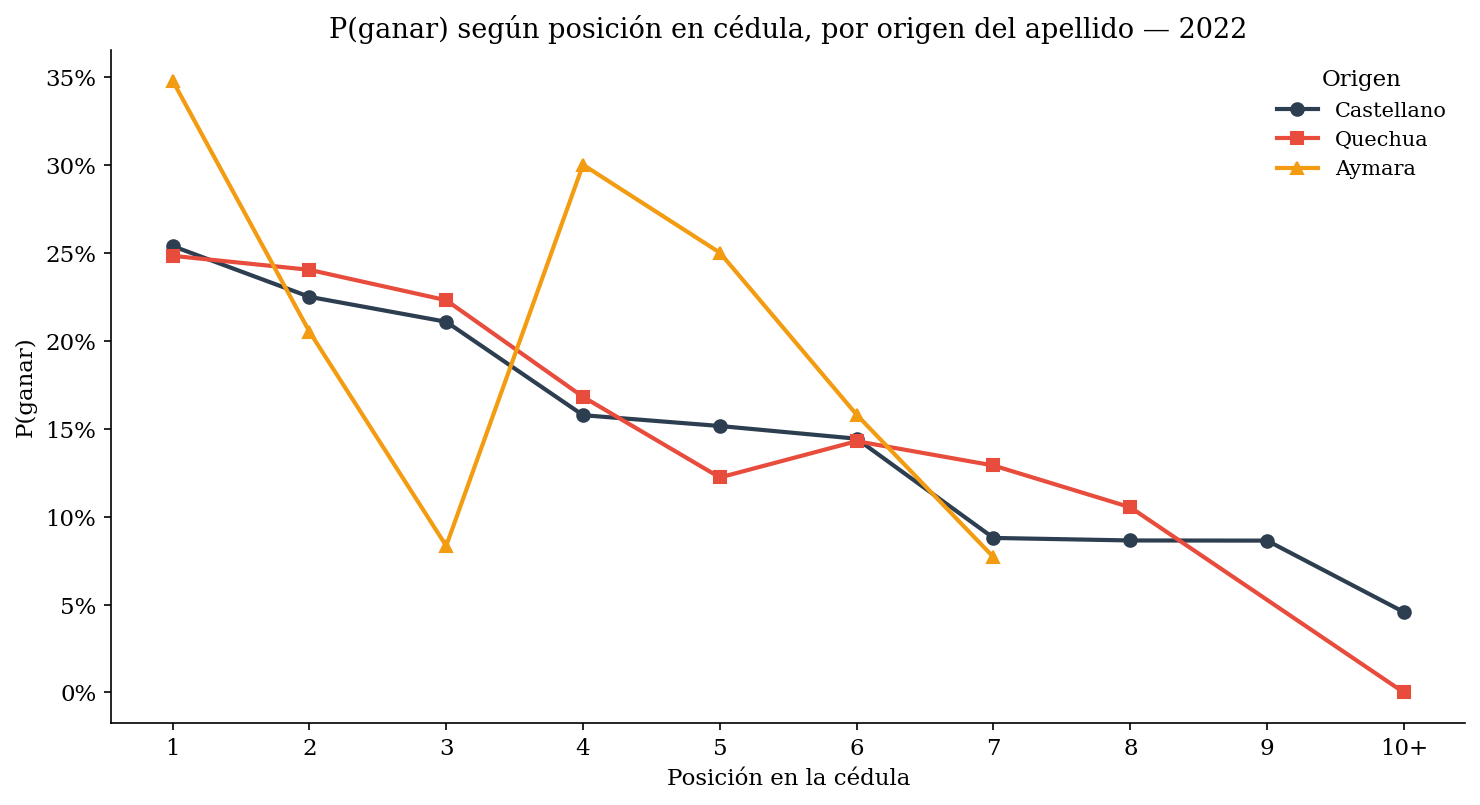


MPL con EF departamento — N = 8,982   R² = 0.0375
Ref.: CASTELLANO
Variable                                                 Coef(pp)       SE       p
----------------------------------------------------------------------------------
posicion_cedula                                            -1.082    0.184  0.0000 ***
C(origen_apellido)[T.QUECHUA]                              +0.232    2.757  0.9329 
C(origen_apellido)[T.AYMARA]                               +1.571    4.645  0.7352 
C(origen_apellido)[T.EXTRANJERO]                           -4.558   10.093  0.6515 
posicion_cedula:C(origen_apellido)[T.QUECHUA]              -0.228    0.530  0.6665 
posicion_cedula:C(origen_apellido)[T.AYMARA]               -0.240    0.806  0.7659 
posicion_cedula:C(origen_apellido)[T.EXTRANJERO]           +1.185    1.699  0.4855 
mujer                                                      -7.353    1.123  0.0000 ***
n_candidatos                                               -1.780    0.174  0.0000 ***



In [11]:
mod_2022 = analisis_anual_apellidos(data[data['año']==2022], 2022)

## 7. Comparación entre años

In [12]:
# Tabla resumen de coeficientes por año
modelos = {'2006':mod_2006, '2010':mod_2010, '2014':mod_2014,
           '2018':mod_2018, '2022':mod_2022}

filas = []
for year, mod in modelos.items():
    if mod is None: continue
    row = {'Año': year, 'N': int(mod.nobs), 'R²': round(mod.rsquared,4)}
    
    b_pos = mod.params['posicion_cedula']
    row['β_pos (pp)'] = round(b_pos*100, 3)
    row['p_pos'] = round(mod.pvalues['posicion_cedula'], 4)
    
    for orig in ['QUECHUA','AYMARA','EXTRANJERO']:
        key_int = f'posicion_cedula:C(origen_apellido)[T.{orig}]'
        key_niv = f'C(origen_apellido)[T.{orig}]'
        if key_int in mod.params.index:
            row[f'β_pos×{orig[:3]} (pp)'] = round(mod.params[key_int]*100, 3)
            row[f'p_pos×{orig[:3]}'] = round(mod.pvalues[key_int], 3)
        if key_niv in mod.params.index:
            row[f'β_{orig[:3]} (pp)'] = round(mod.params[key_niv]*100, 2)
    filas.append(row)

comp = pd.DataFrame(filas)
print('Coeficientes MPL por año (puntos porcentuales, EF departamento):')
print(comp.to_string(index=False))

Coeficientes MPL por año (puntos porcentuales, EF departamento):
 Año     N     R²  β_pos (pp)  p_pos  β_pos×QUE (pp)  p_pos×QUE  β_QUE (pp)  β_pos×AYM (pp)  p_pos×AYM  β_AYM (pp)  β_pos×EXT (pp)  p_pos×EXT  β_EXT (pp)
2006 11059 0.0247      -0.073 0.5752          -0.936      0.034        5.72          -0.530      0.357        1.16          -1.061      0.559        9.34
2010 11137 0.0234      -0.019 0.8864           0.012      0.974       -0.24           0.470      0.518       -0.92           0.782      0.708       -1.26
2014 11455 0.0268       0.194 0.1074          -0.319      0.387        3.07           0.146      0.765       -2.11           0.012      0.995        2.98
2018 10831 0.0340      -0.905 0.0000          -0.686      0.049        1.18          -0.169      0.865        3.59           2.786      0.067      -19.57
2022  8982 0.0375      -1.082 0.0000          -0.228      0.666        0.23          -0.240      0.766        1.57           1.185      0.485       -4.56


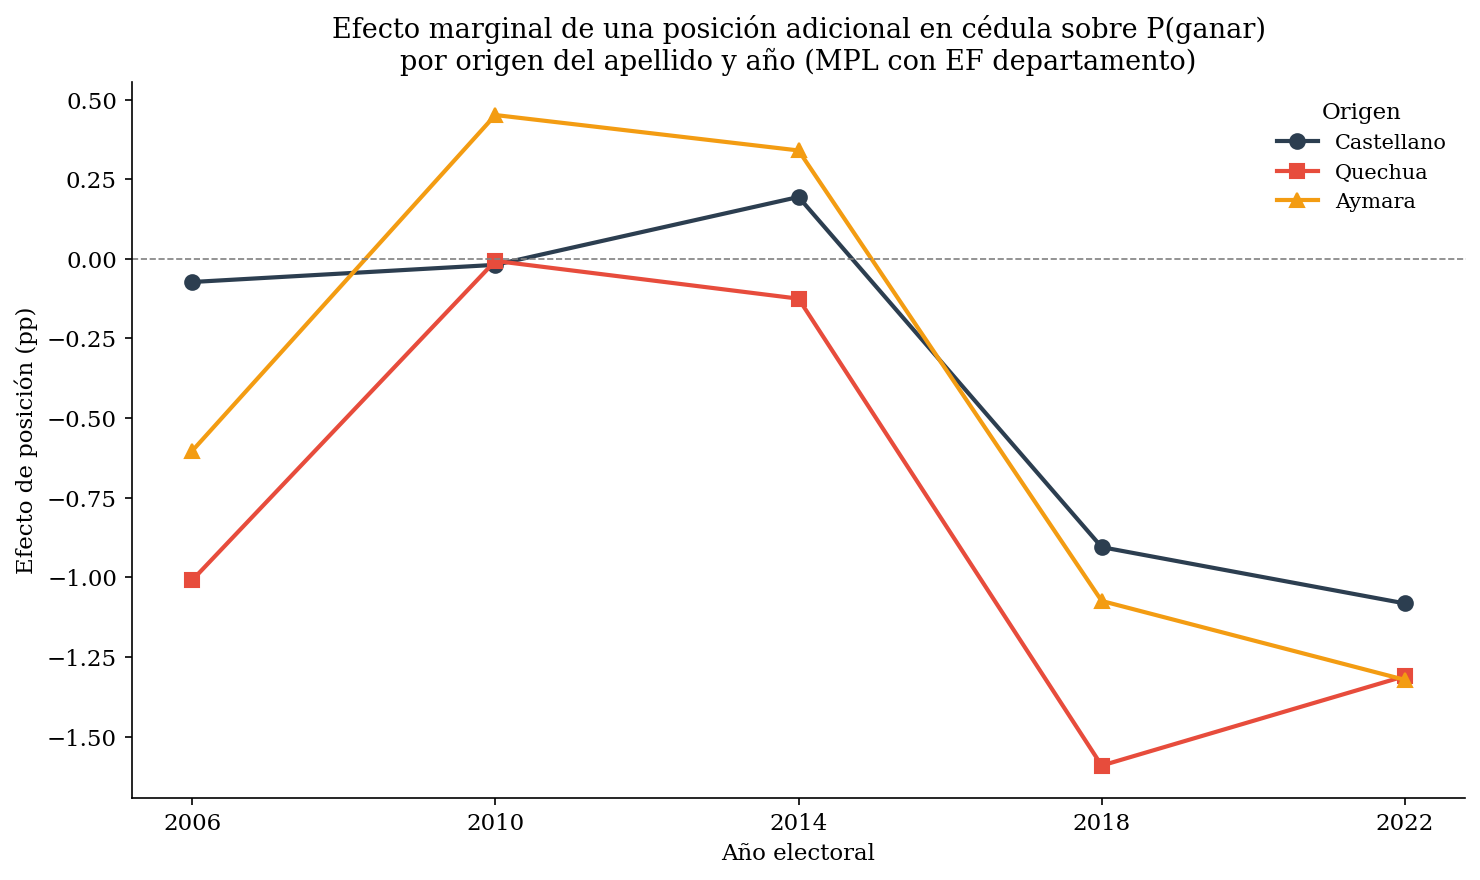

In [13]:
# Gráfico: efecto neto de posición por origen, a lo largo de los años
fig, ax = plt.subplots(figsize=(10, 6))

for orig in ['CASTELLANO','QUECHUA','AYMARA']:
    efecto_por_año = []
    años = []
    for year_str, mod in modelos.items():
        if mod is None: continue
        b_pos = mod.params['posicion_cedula'] * 100
        if orig == 'CASTELLANO':
            efecto_por_año.append(b_pos)
        else:
            key = f'posicion_cedula:C(origen_apellido)[T.{orig}]'
            b_int = mod.params.get(key, 0) * 100
            efecto_por_año.append(b_pos + b_int)
        años.append(int(year_str))
    ax.plot(años, efecto_por_año, marker=MARCADORES.get(orig,'o'),
            color=COLORES.get(orig,'gray'), lw=2, ms=7, label=orig.title())

ax.axhline(0, color='gray', ls='--', lw=0.8)
ax.set_xlabel('Año electoral')
ax.set_ylabel('Efecto de posición (pp)')
ax.set_title('Efecto marginal de una posición adicional en cédula sobre P(ganar)\n'
             'por origen del apellido y año (MPL con EF departamento)')
ax.legend(title='Origen', frameon=False)
ax.set_xticks(años)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'fig_efecto_posicion_por_año_origen.png'),
            dpi=300, bbox_inches='tight')
plt.show()

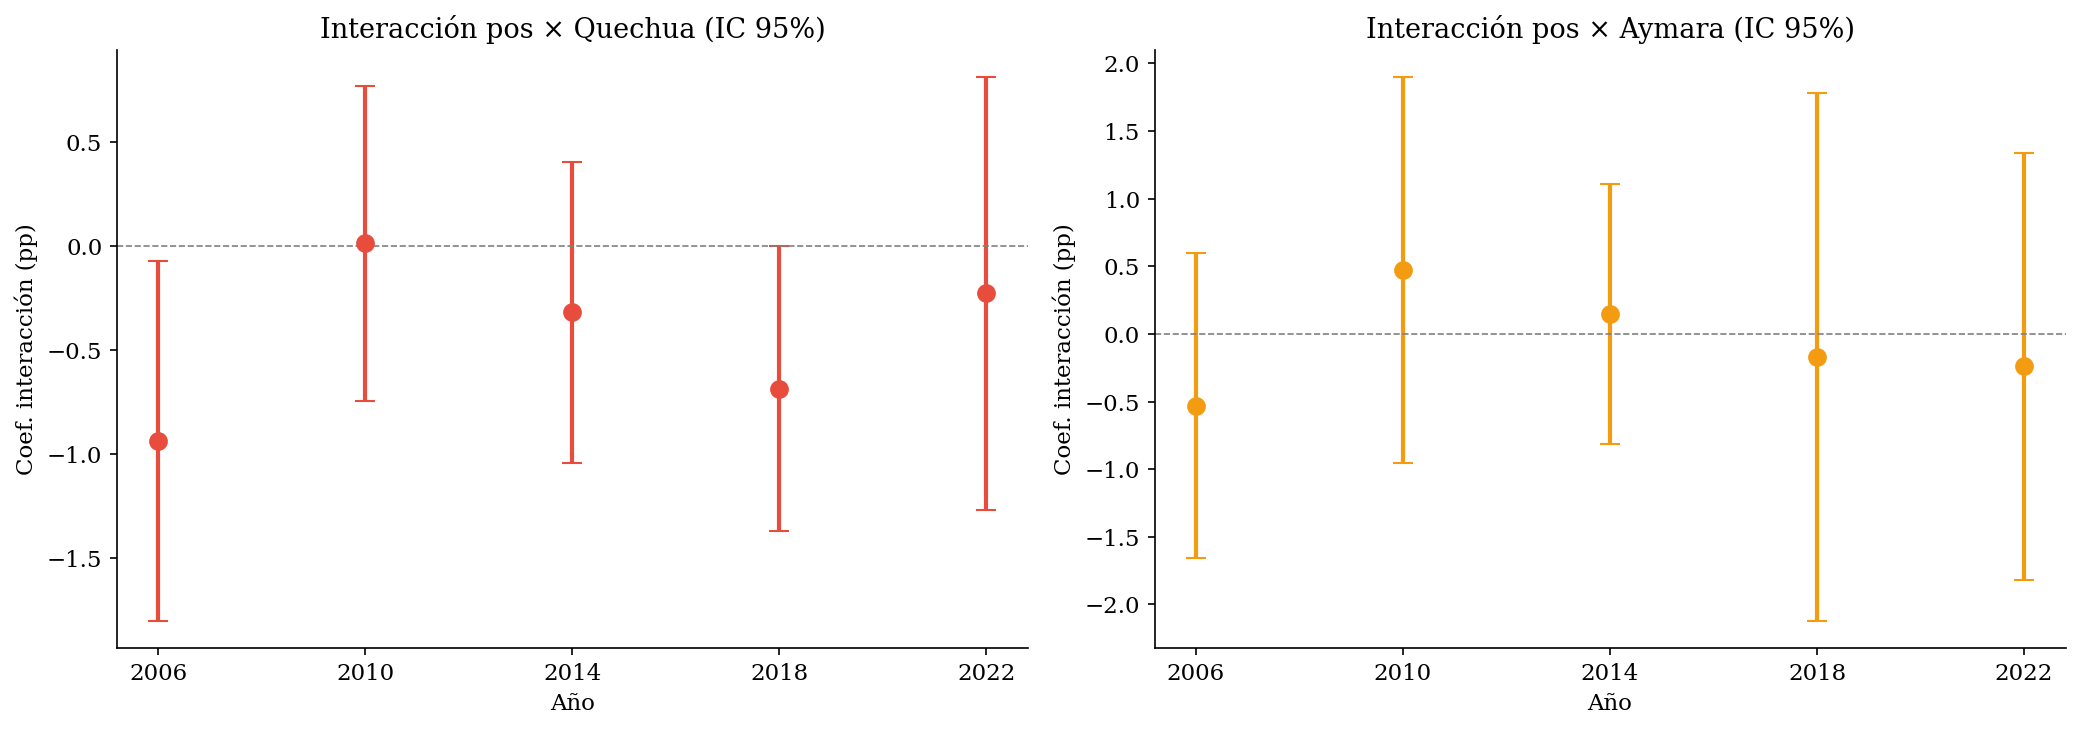

In [14]:
# Coeficiente de interacción pos×QUECHUA con IC 95% por año
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, orig in enumerate(['QUECHUA', 'AYMARA']):
    ax = axes[idx]
    xs, coefs, lo, hi = [], [], [], []
    key = f'posicion_cedula:C(origen_apellido)[T.{orig}]'
    for year_str, mod in modelos.items():
        if mod is None or key not in mod.params.index: continue
        b = mod.params[key] * 100
        se = mod.bse[key] * 100
        xs.append(int(year_str))
        coefs.append(b)
        lo.append(b - 1.96*se)
        hi.append(b + 1.96*se)
    ax.errorbar(xs, coefs,
                yerr=[np.array(coefs)-np.array(lo), np.array(hi)-np.array(coefs)],
                fmt='o', color=COLORES[orig], capsize=5, ms=8, lw=2)
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    ax.set_xlabel('Año')
    ax.set_ylabel('Coef. interacción (pp)')
    ax.set_title(f'Interacción pos × {orig.title()} (IC 95%)')
    ax.set_xticks(xs)

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'fig_interaccion_origen_IC.png'),
            dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# Modelo pooled con EF año + EF departamento (referencia)
dp_all = data.dropna(subset=['posicion_cedula','ganador']).copy()
dp_all['año_str'] = dp_all['año'].astype(str)
dp_all['origen_apellido'] = pd.Categorical(
    dp_all['origen_apellido'],
    categories=['CASTELLANO','QUECHUA','AYMARA','EXTRANJERO'])

mod_pool = smf.ols(
    'ganador ~ posicion_cedula * C(origen_apellido) + mujer + n_candidatos '
    '+ C(año_str) + C(departamento)',
    data=dp_all
).fit(cov_type='HC1')

print('Modelo pooled (EF año + EF departamento):')
print(f'N = {int(mod_pool.nobs):,}   R² = {mod_pool.rsquared:.4f}')
print()
vars_show = ['posicion_cedula',
             'C(origen_apellido)[T.QUECHUA]',
             'C(origen_apellido)[T.AYMARA]',
             'C(origen_apellido)[T.EXTRANJERO]',
             'posicion_cedula:C(origen_apellido)[T.QUECHUA]',
             'posicion_cedula:C(origen_apellido)[T.AYMARA]',
             'posicion_cedula:C(origen_apellido)[T.EXTRANJERO]',
             'mujer', 'n_candidatos']

for v in vars_show:
    if v in mod_pool.params.index:
        sig = '***' if mod_pool.pvalues[v]<0.01 else '**' if mod_pool.pvalues[v]<0.05 \
              else '*' if mod_pool.pvalues[v]<0.1 else ''
        print(f'  {v:<55} {mod_pool.params[v]*100:>+8.3f} pp  (p={mod_pool.pvalues[v]:.4f}) {sig}')

Modelo pooled (EF año + EF departamento):
N = 53,464   R² = 0.0283

  posicion_cedula                                           -0.323 pp  (p=0.0000) ***
  C(origen_apellido)[T.QUECHUA]                             +1.848 pp  (p=0.0856) *
  C(origen_apellido)[T.AYMARA]                              +0.734 pp  (p=0.6935) 
  C(origen_apellido)[T.EXTRANJERO]                          -1.938 pp  (p=0.6712) 
  posicion_cedula:C(origen_apellido)[T.QUECHUA]             -0.387 pp  (p=0.0319) **
  posicion_cedula:C(origen_apellido)[T.AYMARA]              -0.094 pp  (p=0.7725) 
  posicion_cedula:C(origen_apellido)[T.EXTRANJERO]          +0.741 pp  (p=0.3784) 
  mujer                                                     -6.391 pp  (p=0.0000) ***
  n_candidatos                                              -1.554 pp  (p=0.0000) ***
